In [8]:
import pandas as pd
import numpy as np

stolen_water = pd.read_csv('./csvs/consum din cauza irigării.csv', sep=';')

stolen_water['x'] = pd.to_datetime(stolen_water['x'], format='%d/%m/%Y %H:%M')

stolen_water['Date'] = pd.to_datetime(stolen_water['x']).dt.date.astype('datetime64[ns]')
stolen_water['Hour'] = pd.to_datetime(stolen_water['x'], format='%d/%m/%Y %H:%M').dt.hour

# stolen_water.info()

# missing_values = stolen_water.isnull().sum()
# print("Valori lipsă:\n", missing_values)

# print(stolen_water.describe())

hourly_stats = stolen_water.groupby("Hour")["y"].agg(["mean", "median", "std"])

threshold_95 = np.percentile(stolen_water["y"], 95)
stolen_water["is_anomalous"] = stolen_water["y"] > threshold_95

hourly_profile = stolen_water.groupby("Hour")["y"].mean()
stolen_water["alert_threshold"] = stolen_water["Hour"].map(lambda x: hourly_stats.loc[x, "mean"] + 2 * hourly_stats.loc[x, "std"])

stolen_water["anomaly_type"] = np.where(
    stolen_water["y"] > threshold_95, "Potential Theft",
    np.where(stolen_water["y"] > stolen_water["alert_threshold"], "Possible Leak", "Normal Usage")
)

print(f"Prag percentilă 95: {threshold_95}")
print("Anomalii detectate:\n", stolen_water[stolen_water["is_anomalous"]])
print("Profil consum normal:\n", hourly_profile)

stolen_water.to_csv("procesat_consum_irigare.csv", index=False)

Prag percentilă 95: 60.0
Anomalii detectate:
                       x     y       Date  Hour  is_anomalous  alert_threshold  \
4   2025-03-19 12:00:00    62 2025-03-19    12          True        63.325148   
6   2025-03-19 14:00:00    62 2025-03-19    14          True        64.976669   
7   2025-03-19 15:00:00   872 2025-03-19    15          True       906.059408   
8   2025-03-19 16:00:00    61 2025-03-19    16          True        64.060932   
10  2025-03-19 18:00:00  1224 2025-03-19    18          True      2198.964521   
34  2025-03-20 18:00:00  1411 2025-03-20    18          True      2198.964521   
55  2025-03-21 15:00:00   991 2025-03-21    15          True       906.059408   
129 2025-03-24 17:00:00  1085 2025-03-24    17          True      1445.960360   
154 2025-03-25 18:00:00  2092 2025-03-25    18          True      2198.964521   
178 2025-03-26 18:00:00  1876 2025-03-26    18          True      2198.964521   
202 2025-03-27 18:00:00  1623 2025-03-27    18          True   

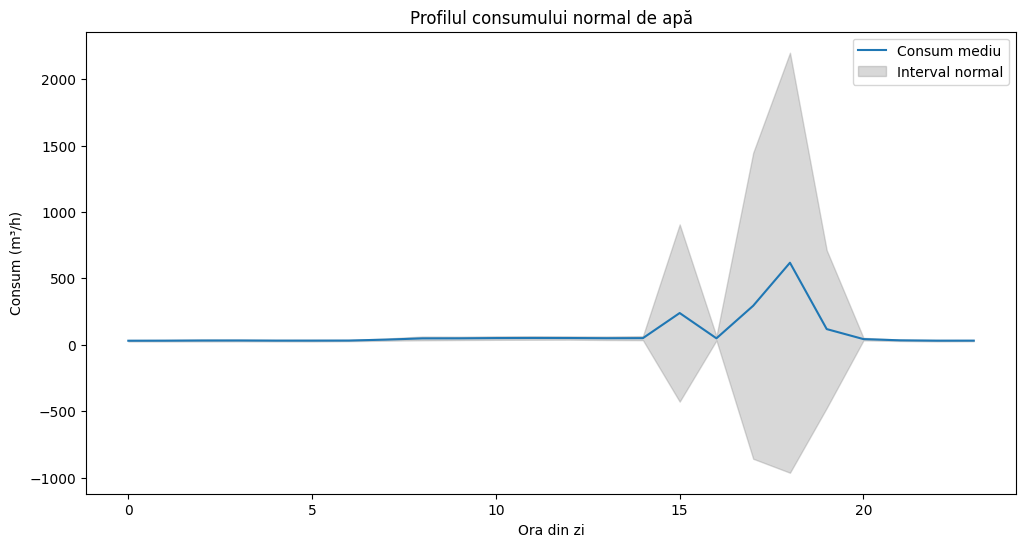

Profil consum normal:
             mean  median         std
Hour                                
0      30.375000    29.0    2.753785
1      30.750000    30.0    2.977695
2      32.000000    31.0    3.585686
3      32.187500    31.0    3.350995
4      31.125000    30.0    2.986079
5      31.125000    30.0    3.222318
6      31.625000    31.0    2.362908
7      38.562500    39.0    3.999479
8      48.000000    50.0    7.097535
9      48.352941    50.0    6.363383
10     50.352941    52.0    6.632695
11     51.058824    52.0    6.703270
12     50.764706    52.0    6.280221
13     49.176471    51.0    6.701075
14     49.823529    52.0    7.576570
15    238.941176    53.0  333.559116
16     48.470588    51.0    7.795172
17    293.705882    51.0  576.127239
18    617.705882    52.0  790.629319
19    117.941176    49.0  296.959271
20     42.588235    44.0    4.730999
21     33.294118    33.0    2.616408
22     30.764706    30.0    2.704843
23     31.000000    30.0    2.221111
Anomalii detect

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Citirea fișierului CSV
stolen_water = pd.read_csv('./csvs/consum din cauza irigării.csv', sep=';')

# Conversia timestamp-ului în format datetime
stolen_water['x'] = pd.to_datetime(stolen_water['x'], format='%d/%m/%Y %H:%M')

# Separarea datei și orei
stolen_water['Date'] = pd.to_datetime(stolen_water['x']).dt.date.astype('datetime64[ns]')
stolen_water['Hour'] = pd.to_datetime(stolen_water['x'], format='%d/%m/%Y %H:%M').dt.hour

# Crearea profilului normal de consum
hourly_profile = stolen_water.groupby("Hour")["y"].agg(["mean", "median", "std"])

# Definirea pragului de alertă: consumul normal ± 2 * deviația standard
stolen_water["alert_threshold"] = stolen_water["Hour"].map(lambda x: hourly_profile.loc[x, "mean"] + 2 * hourly_profile.loc[x, "std"])

# Detectarea anomaliilor față de profilul normal
stolen_water["is_anomalous"] = stolen_water["y"] > stolen_water["alert_threshold"]

# Vizualizarea consumului orar
plt.figure(figsize=(12, 6))
plt.plot(hourly_profile.index, hourly_profile["mean"], label="Consum mediu")
plt.fill_between(hourly_profile.index, hourly_profile["mean"] - 2 * hourly_profile["std"], 
                 hourly_profile["mean"] + 2 * hourly_profile["std"], color='gray', alpha=0.3, label="Interval normal")
plt.xlabel("Ora din zi")
plt.ylabel("Consum (m³/h)")
plt.title("Profilul consumului normal de apă")
plt.legend()
plt.show()

# Afișăm profilul normal al consumului și anomaliile detectate
print("Profil consum normal:\n", hourly_profile)
print("Anomalii detectate:\n", stolen_water[stolen_water["is_anomalous"]])

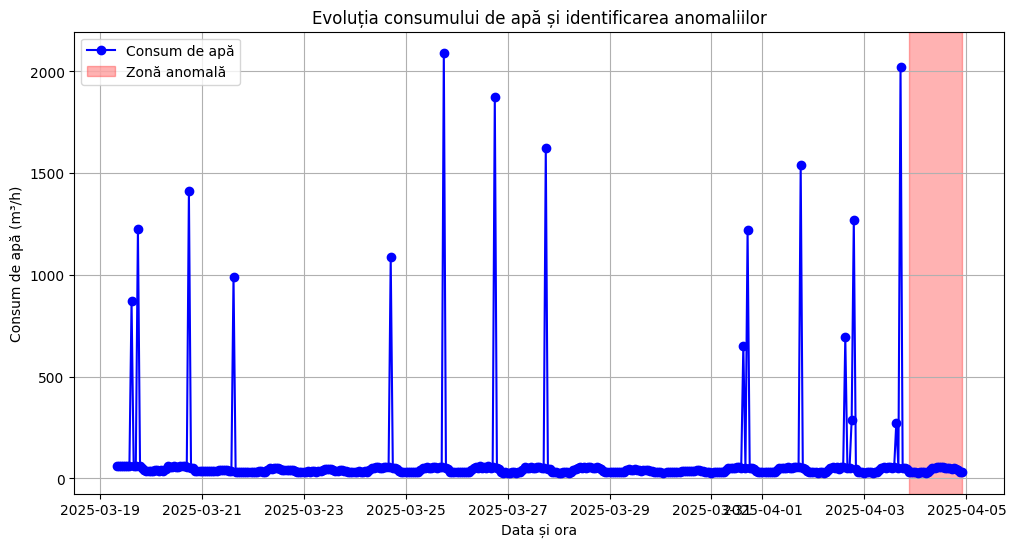

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Citirea datelor din fișier
df = pd.read_csv('./csvs/consum din cauza irigării.csv', sep=';')

# Convertirea timestamp-ului
df["x"] = pd.to_datetime(df["x"], format="%d/%m/%Y %H:%M")

# Crearea graficului de consum
plt.figure(figsize=(12, 6))
plt.plot(df["x"], df["y"], marker='o', linestyle='-', color='blue', label="Consum de apă")

# Evidențierea anomaliilor (după 3 aprilie)
plt.axvspan(pd.to_datetime("3/4/2025 21:00", format="%d/%m/%Y %H:%M"), 
            pd.to_datetime("4/4/2025 22:00", format="%d/%m/%Y %H:%M"), 
            color='red', alpha=0.3, label="Zonă anomală")

plt.xlabel("Data și ora")
plt.ylabel("Consum de apă (m³/h)")
plt.title("Evoluția consumului de apă și identificarea anomaliilor")
plt.legend()
plt.grid()
plt.show()

Distribuția anomaliilor:
 anomaly_type
Normal Usage       384
Possible Leak       13
Potential Theft      1
Name: count, dtype: int64


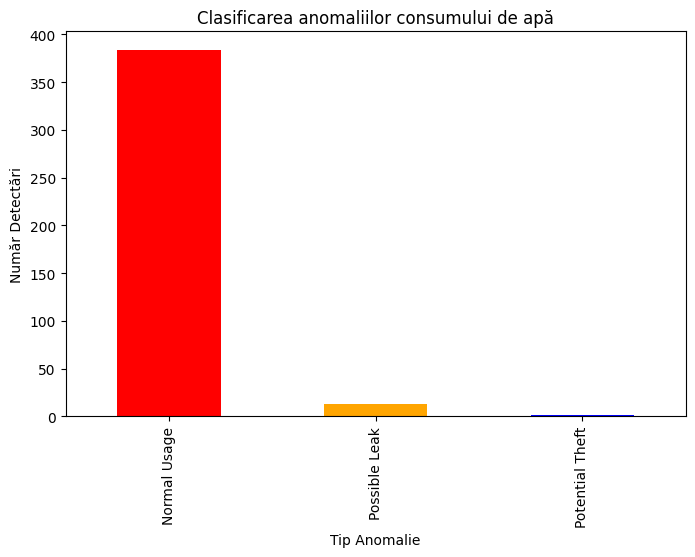

In [12]:
import pandas as pd
import numpy as np

# Citirea fișierului procesat anterior
stolen_water = pd.read_csv("procesat_consum_irigare.csv")

# Definirea pragurilor pentru clasificarea anomaliilor
stolen_water["anomaly_type"] = np.where(
    stolen_water["y"] > stolen_water["alert_threshold"] * 1.5, "Potential Theft",
    np.where(stolen_water["y"] > stolen_water["alert_threshold"], "Possible Leak", "Normal Usage")
)

# Contorizarea fiecărui tip de anomalie
anomaly_counts = stolen_water["anomaly_type"].value_counts()
print("Distribuția anomaliilor:\n", anomaly_counts)

# Vizualizarea distribuției anomaliilor
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
anomaly_counts.plot(kind="bar", color=["red", "orange", "blue"])
plt.xlabel("Tip Anomalie")
plt.ylabel("Număr Detectări")
plt.title("Clasificarea anomaliilor consumului de apă")
plt.show()

# Salvarea datasetului procesat cu anomaliile clasificate
stolen_water.to_csv("procesat_consum_final.csv", index=False)